# Week 02 consolidated Bayesian optimisation notebook

This notebook presents Functions 1–8 in one systematic analytical record. Every function follows the same eleven-stage sequence below. UCB results are unevaluated proposals and are never appended as returned observations.

**Evidence used:** starter observations plus immutable-ledger returns through Week 01.

## Table of contents

1. Create week's_dataset by appending the previous output results
2. Extract the function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

# Function 1

Function 1 uses the verified evidence available before Week 02.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 1, 2, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [2]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
1,starter,0.574329,0.879898,1.033078e-46
2,starter,0.731024,0.733000,7.710875e-16
3,starter,0.840353,0.264732,3.341771e-124
4,starter,0.650114,0.681526,-3.606063e-03
5,starter,0.410437,0.147554,-2.159249e-54
6,starter,0.312691,0.078723,-2.089093e-91
7,starter,0.683418,0.861057,2.535001e-40
8,starter,0.082507,0.403488,3.606771e-81
9,starter,0.883890,0.582254,6.229856e-48


## 2. Extract the function

In [3]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 1: 2 input dimensions, 11 verified observations


## 3. Check shapes and missing values

In [4]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(11, 2)"
1,output shape,"(11,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [5]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,11.0,0.532973,0.251413,0.082507,3.469719e-01,5.743292e-01,7.072209e-01,8.838898e-01
x2,11.0,0.576900,0.306967,0.078723,3.341096e-01,6.815264e-01,8.120084e-01,9.507140e-01
output,11.0,-0.000328,0.001087,-0.003606,-1.044547e-91,3.606771e-81,5.476884e-47,7.710875e-16


## 5. Plot the output trend

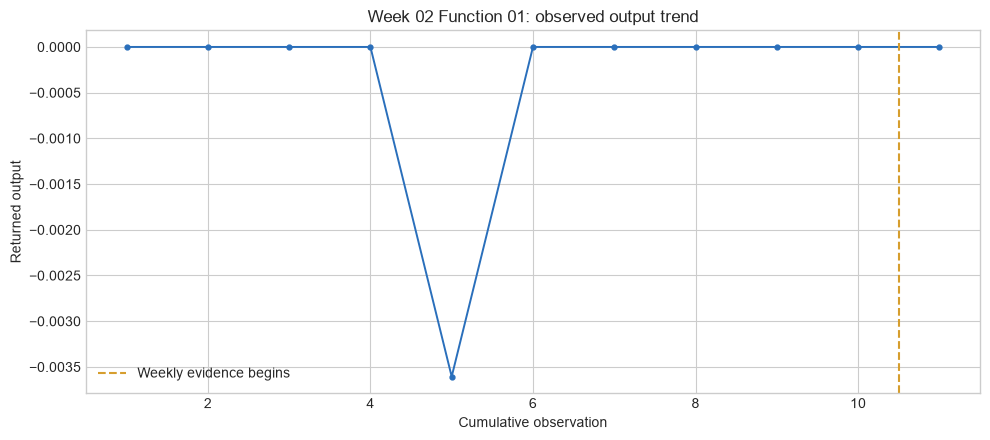

In [6]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

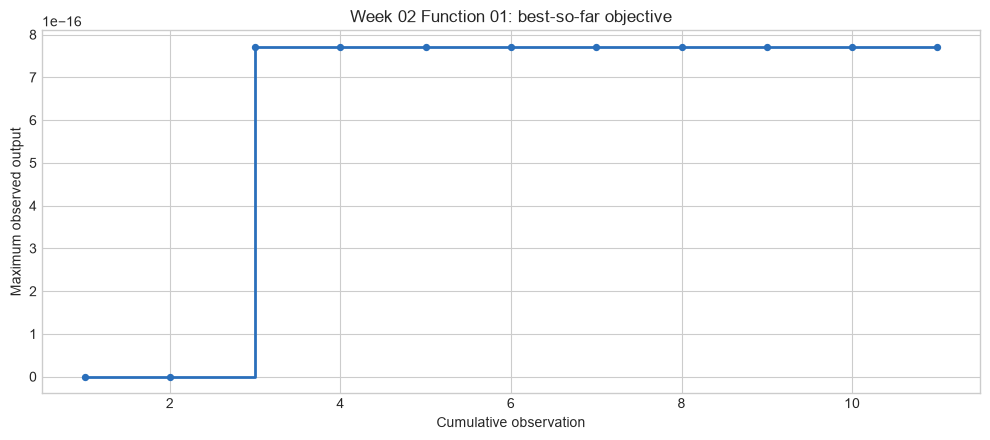

In [7]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [8]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,3,starter,0.731024,0.733,7.710875e-16


## 8. Plot the correlation heatmap

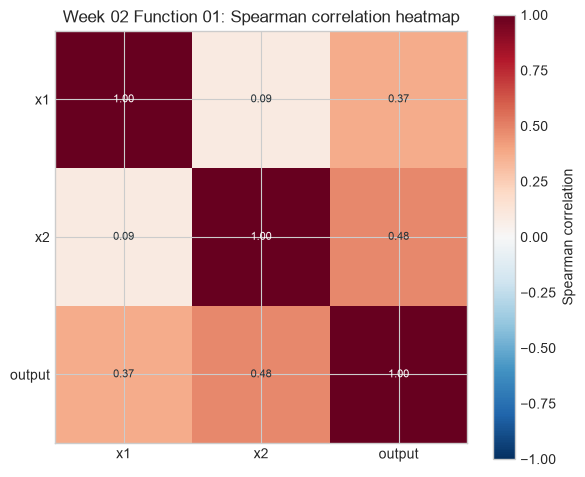

In [9]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

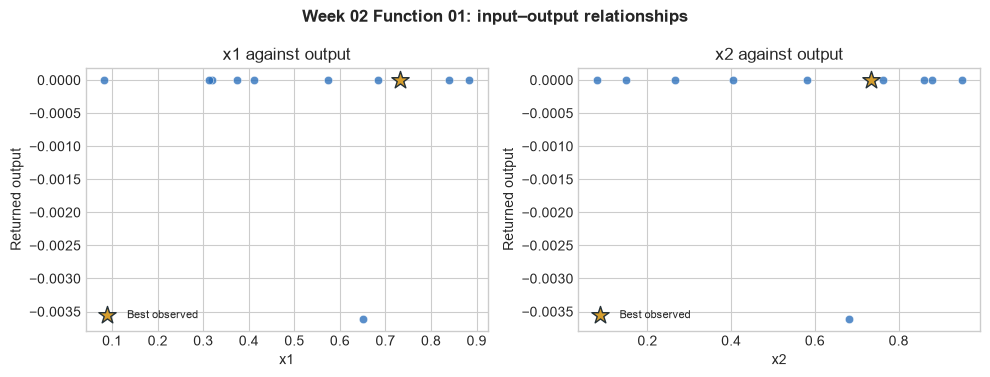

In [10]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [11]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.02**2 * Matern(length_scale=[0.0166, 10], nu=2.5) + WhiteKernel(noise_level=7.22e-07)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [12]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_1:0.705334-0.111153


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,2,1,2.0,0.705334,0.111153,-0.000021,0.000946,0.00187,proposed_not_evaluated


# Function 2

Function 2 uses the verified evidence available before Week 02.

In [13]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 2, 2, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [14]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
1,starter,0.877791,0.778628,0.420586
2,starter,0.142699,0.349005,-0.065624
3,starter,0.845275,0.711120,0.293993
4,starter,0.454647,0.290455,0.214965
5,starter,0.577713,0.771973,0.023106
6,starter,0.438166,0.685018,0.244619
7,starter,0.341750,0.028698,0.038749
8,starter,0.338648,0.213867,-0.013858
9,starter,0.702637,0.926564,0.611205


## 2. Extract the function

In [15]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 2: 2 input dimensions, 11 verified observations


## 3. Check shapes and missing values

In [16]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(11, 2)"
1,output shape,"(11,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [17]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,11.0,0.523606,0.230383,0.142699,0.358145,0.454647,0.684218,0.877791
x2,11.0,0.530001,0.334322,0.028698,0.252161,0.685018,0.775300,0.950714
output,11.0,0.206810,0.238859,-0.065624,0.004624,0.214965,0.357290,0.611205


## 5. Plot the output trend

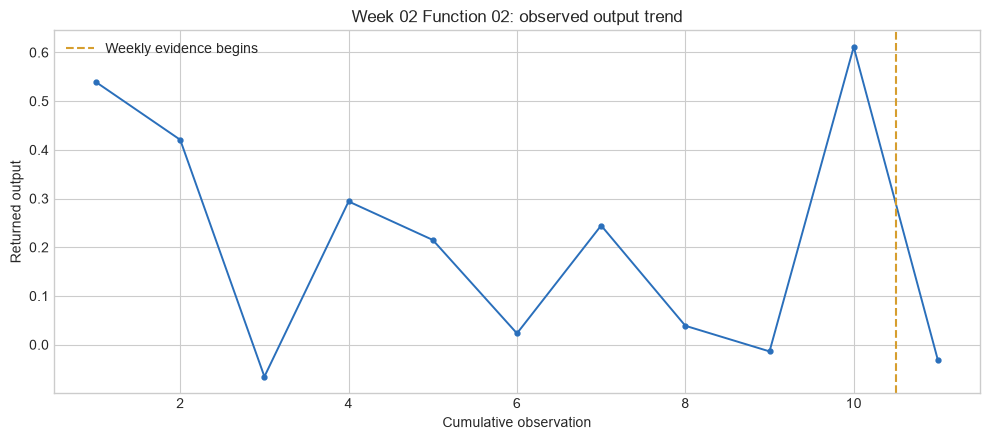

In [18]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

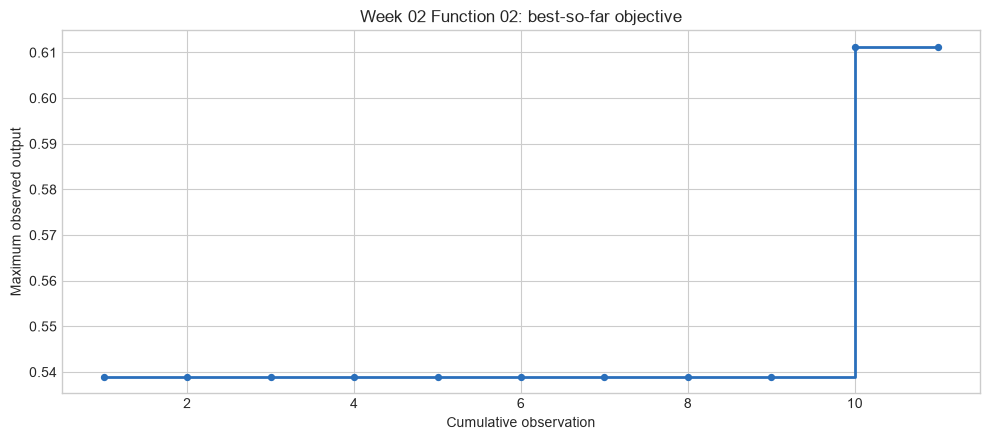

In [19]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [20]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,10,starter,0.702637,0.926564,0.611205


## 8. Plot the correlation heatmap

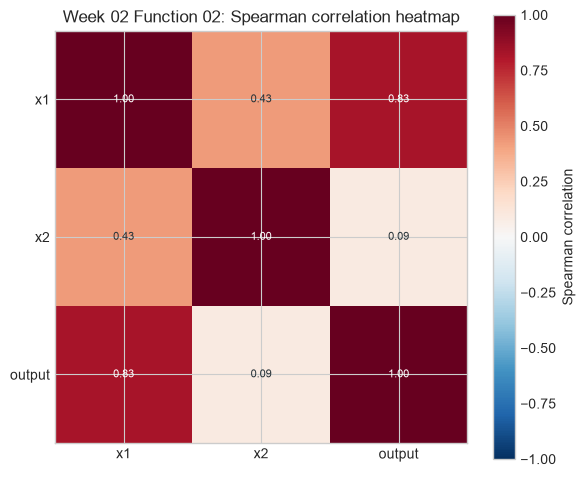

In [21]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

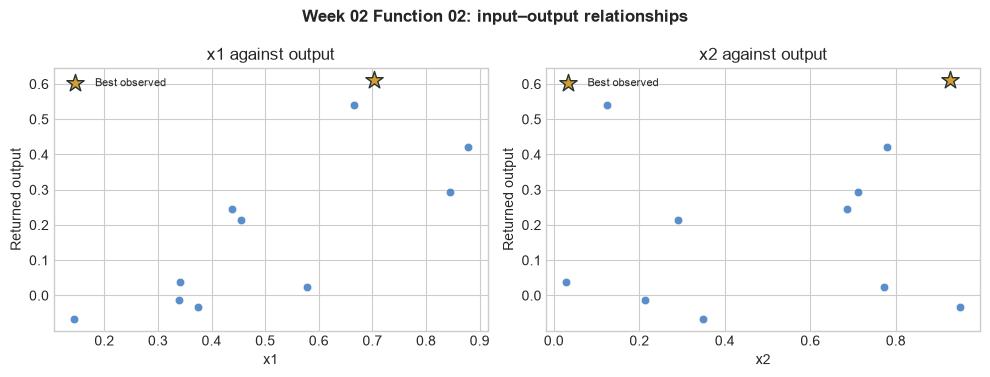

In [22]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [23]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.984**2 * Matern(length_scale=[0.0645, 10], nu=2.5) + WhiteKernel(noise_level=0.027)
Training R²: 0.9953


## 11. Apply UCB to generate the next query point

In [24]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_2:0.739916-0.003069


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,2,2,2.0,0.739916,0.003069,0.485256,0.134094,0.753445,proposed_not_evaluated


# Function 3

Function 3 uses the verified evidence available before Week 02.

In [25]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 3, 3, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [26]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,output
observation,,,,,
6,starter,0.151837,0.439991,0.990882,-0.398926
7,starter,0.645503,0.397143,0.919771,-0.113869
8,starter,0.746912,0.284196,0.226300,-0.131461
9,starter,0.170477,0.697032,0.149169,-0.094190
10,starter,0.220549,0.297825,0.343555,-0.046947
11,starter,0.666014,0.671985,0.246295,-0.105965
12,starter,0.046809,0.231360,0.770618,-0.118048
13,starter,0.600097,0.725136,0.066089,-0.036378
14,starter,0.965995,0.861120,0.566829,-0.056758


## 2. Extract the function

In [27]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 3: 3 input dimensions, 16 verified observations


## 3. Check shapes and missing values

In [28]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(16, 3)"
1,output shape,"(16,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [29]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,16.0,0.411244,0.265861,0.046809,0.171263,0.394984,0.611449,0.965995
x2,16.0,0.526989,0.228113,0.219917,0.332394,0.525792,0.678247,0.941360
x3,16.0,0.398447,0.275056,0.066089,0.241296,0.302883,0.485362,0.990882
output,16.0,-0.103026,0.085828,-0.398926,-0.112559,-0.100077,-0.047743,-0.034835


## 5. Plot the output trend

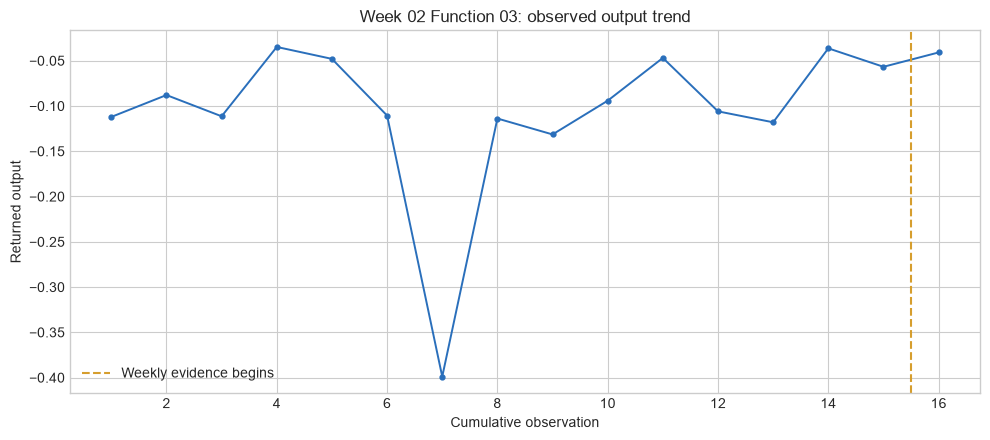

In [30]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

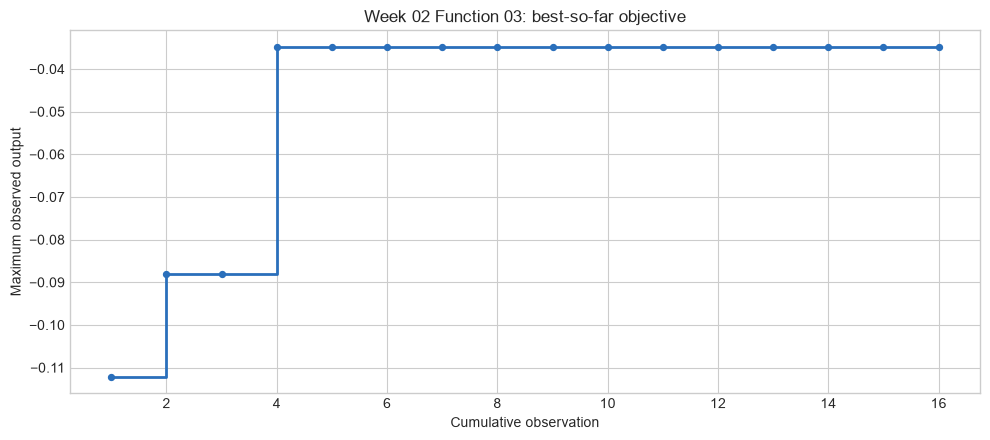

In [31]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [32]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,output
0,4,starter,0.492581,0.611593,0.340176,-0.034835


## 8. Plot the correlation heatmap

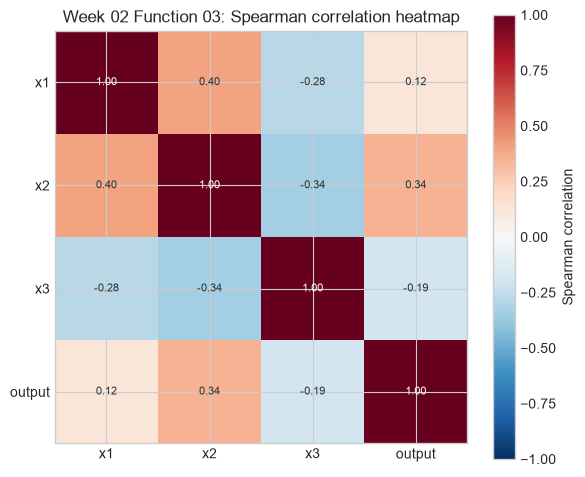

In [33]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

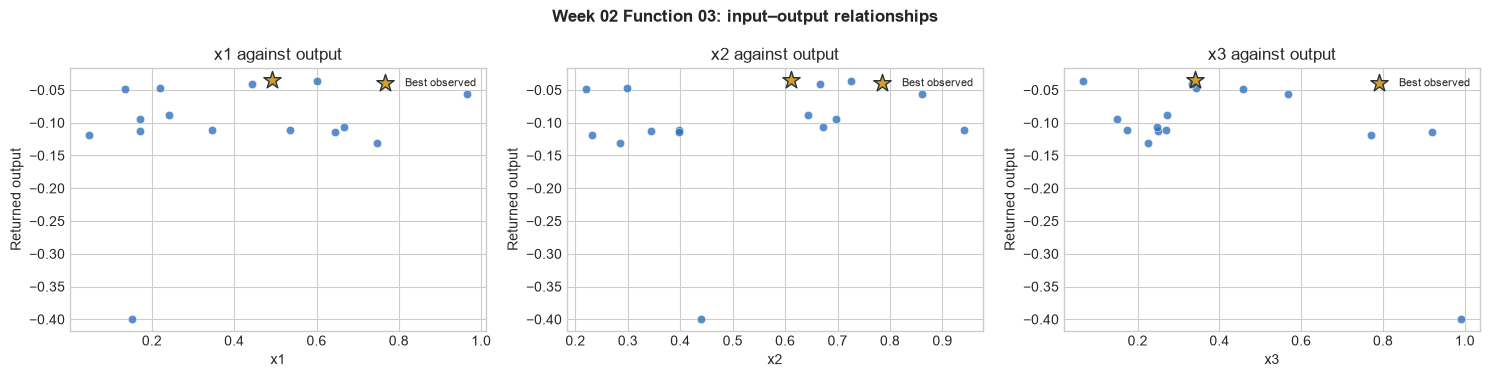

In [34]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [35]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.49**2 * Matern(length_scale=[10, 1.51, 0.105], nu=2.5) + WhiteKernel(noise_level=1.59e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [36]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_3:0.794150-0.027107-0.001899


,week,function,kappa,x1,x2,x3,predicted_mean,predicted_std,ucb_score,status
0,2,3,2.0,0.79415,0.027107,0.001899,-0.049982,0.088282,0.126582,proposed_not_evaluated


# Function 4

Function 4 uses the verified evidence available before Week 02.

In [37]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 4, 4, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [38]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
21,starter,0.170347,0.756959,0.276520,0.531231,-11.565742
22,starter,0.859657,0.919592,0.206139,0.097797,-26.857786
23,starter,0.282138,0.505987,0.530531,0.096302,-7.966775
24,starter,0.326076,0.472367,0.453192,0.105887,-6.702089
25,starter,0.948389,0.894513,0.851638,0.552196,-32.625660
26,starter,0.664955,0.046566,0.116777,0.793718,-19.989498
27,starter,0.577766,0.428772,0.425826,0.249007,-4.025542
28,starter,0.738613,0.482103,0.709366,0.503970,-13.122782
29,starter,0.854811,0.493965,0.735310,0.808092,-23.139428


## 2. Extract the function

In [39]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 4: 4 input dimensions, 31 verified observations


## 3. Check shapes and missing values

In [40]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(31, 4)"
1,output shape,"(31,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [41]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,31.0,0.543282,0.289075,0.037825,0.266542,0.577766,0.774002,0.985622
x2,31.0,0.476074,0.303775,0.006250,0.155668,0.499588,0.741294,0.919592
x3,31.0,0.457839,0.260911,0.042186,0.219731,0.438806,0.708006,0.939178
x4,31.0,0.462387,0.294796,0.081517,0.200835,0.494932,0.746945,0.999483
output,31.0,-16.964037,7.182537,-32.625660,-21.048893,-16.026400,-12.711725,-4.025542


## 5. Plot the output trend

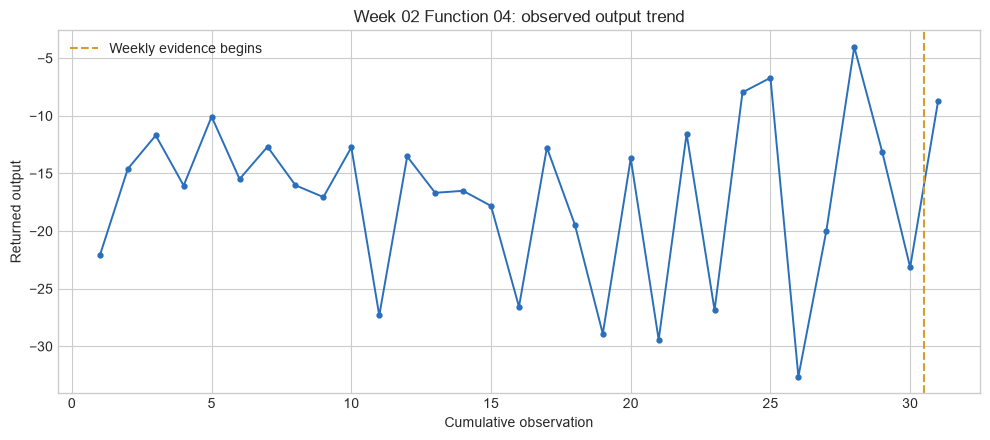

In [42]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

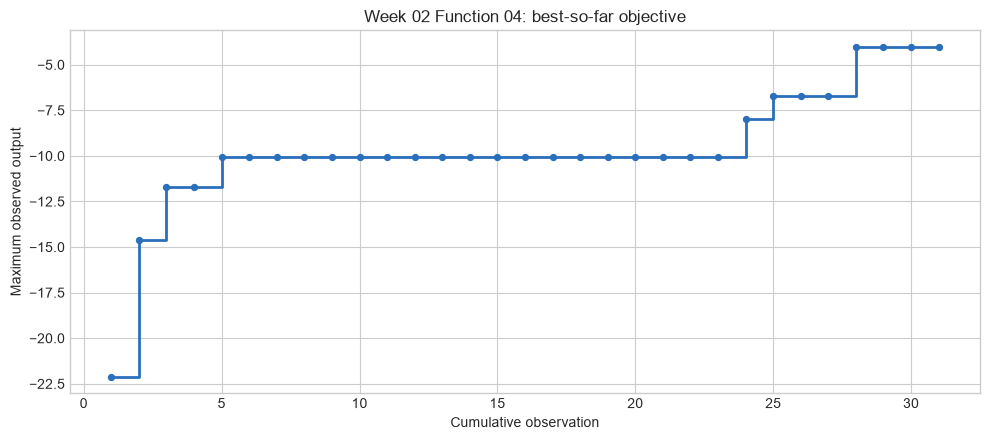

In [43]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [44]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,28,starter,0.577766,0.428772,0.425826,0.249007,-4.025542


## 8. Plot the correlation heatmap

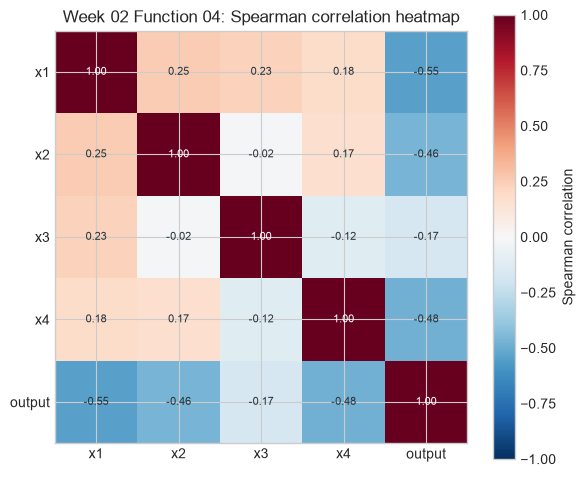

In [45]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

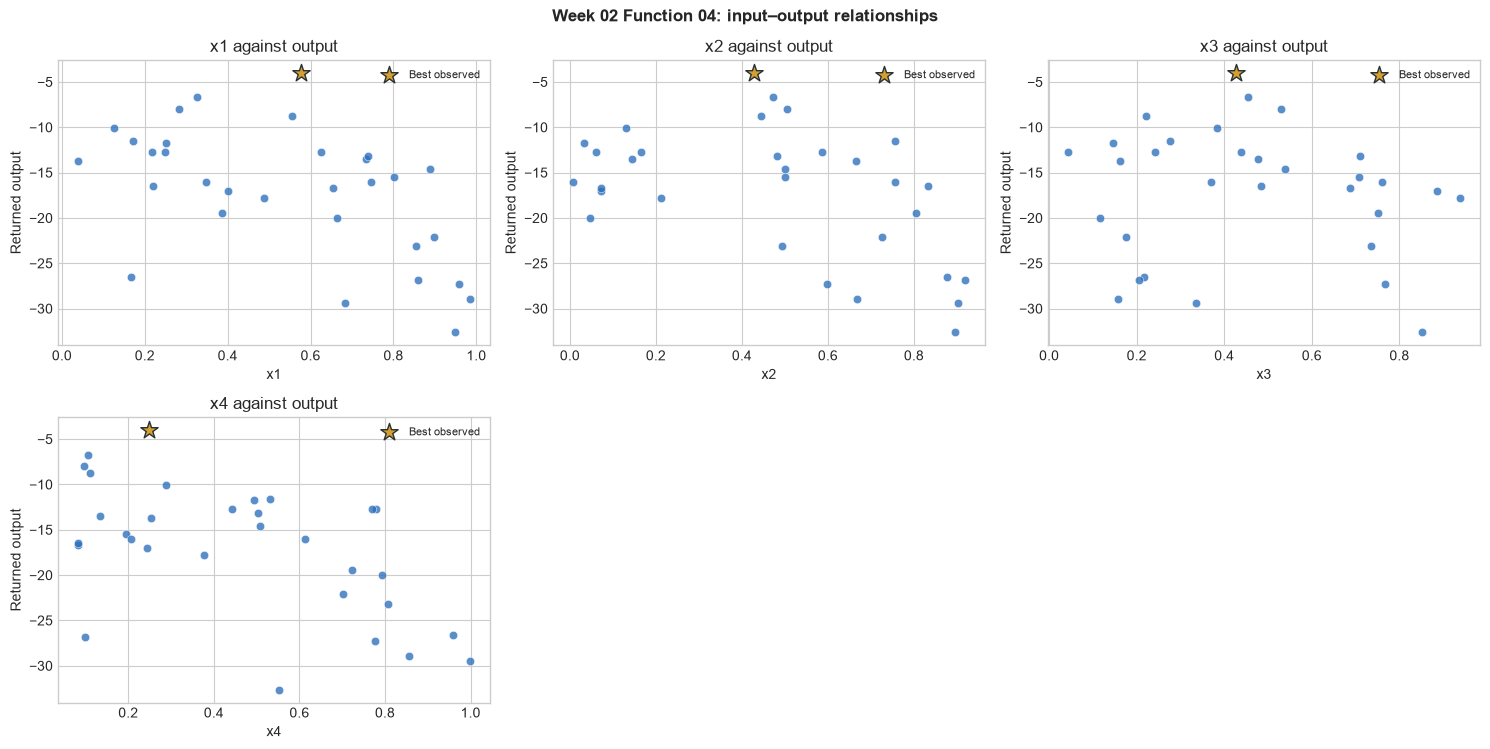

In [46]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [47]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 4.27**2 * Matern(length_scale=[1.9, 1.73, 1.85, 1.82], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [48]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_4:0.353852-0.428092-0.303756-0.455497


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,2,4,2.0,0.353852,0.428092,0.303756,0.455497,-2.557144,0.958867,-0.639411,proposed_not_evaluated


# Function 5

Function 5 uses the verified evidence available before Week 02.

In [49]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 5, 4, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [50]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
11,starter,0.583973,0.147243,0.348097,0.428615,64.420147
12,starter,0.306889,0.316878,0.622634,0.095399,63.476716
13,starter,0.511142,0.817957,0.728710,0.112354,79.729130
14,starter,0.438933,0.774092,0.378167,0.933696,355.806818
15,starter,0.224189,0.846480,0.879484,0.878516,1088.859618
16,starter,0.725262,0.479870,0.088947,0.759760,28.866752
17,starter,0.355482,0.639619,0.417618,0.122604,45.181570
18,starter,0.119879,0.862540,0.643331,0.849804,431.612757
19,starter,0.126885,0.153430,0.770162,0.190518,9.972332


## 2. Extract the function

In [51]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 5: 4 input dimensions, 21 verified observations


## 3. Check shapes and missing values

In [52]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(21, 4)"
1,output shape,"(21,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [53]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,21.0,0.449140,0.227372,0.119879,0.224189,0.438933,0.677491,0.836478
x2,21.0,0.515124,0.277287,0.038193,0.316878,0.536518,0.774092,0.862540
x3,21.0,0.497065,0.256010,0.088947,0.323806,0.479592,0.663893,0.879484
x4,21.0,0.512995,0.312095,0.072880,0.190518,0.473113,0.814870,0.957644
output,21.0,195.918620,319.636559,0.112940,24.423088,64.420147,233.223610,1088.859618


## 5. Plot the output trend

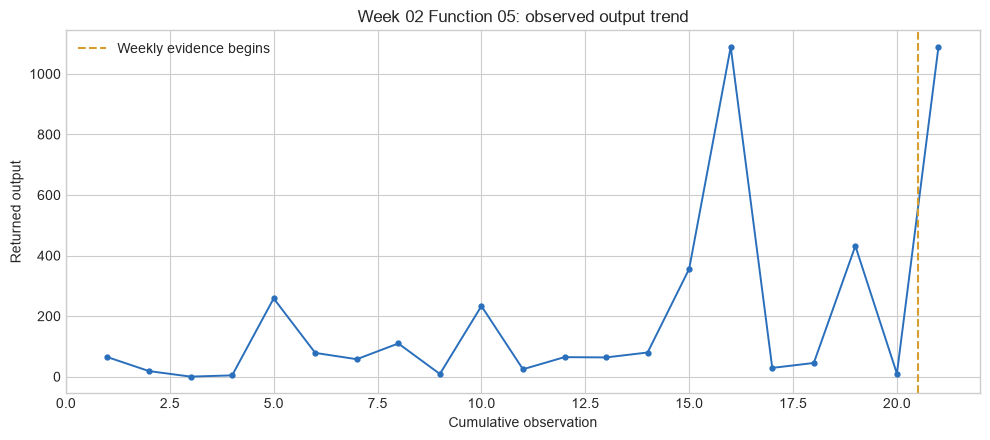

In [54]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

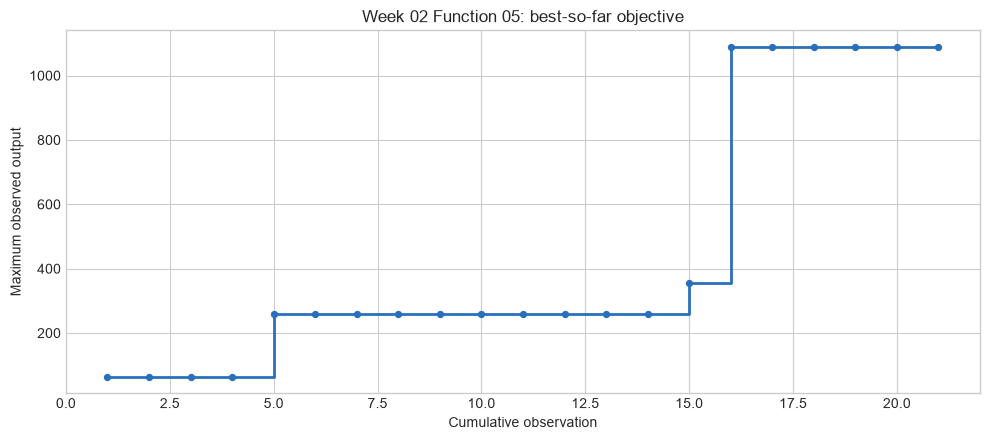

In [55]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [56]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,16,starter,0.224189,0.84648,0.879484,0.878516,1088.859618


## 8. Plot the correlation heatmap

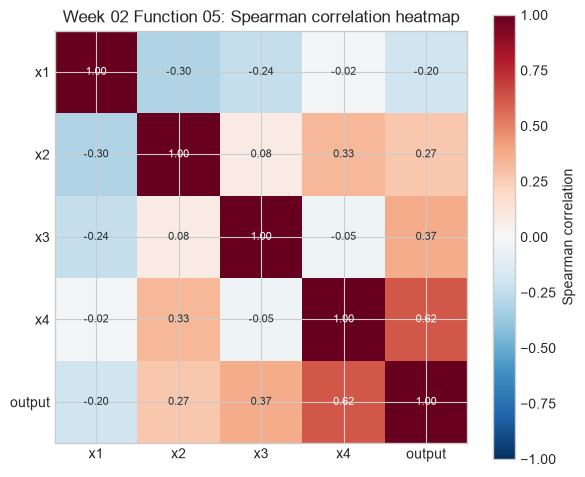

In [57]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

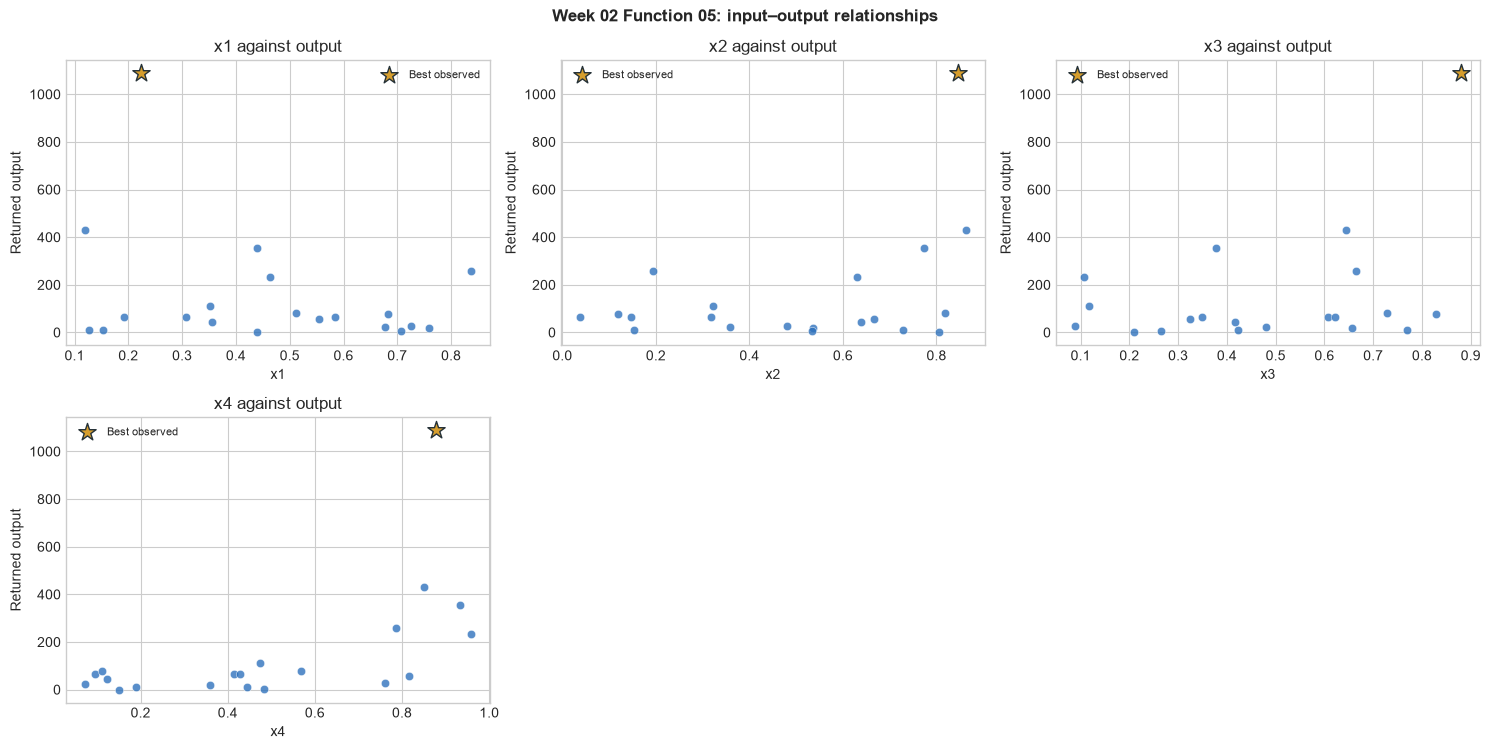

In [58]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [59]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.76**2 * Matern(length_scale=[10, 9.27, 0.761, 0.423], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [60]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_5:0.753964-0.203074-0.988705-0.996565


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,2,5,2.0,0.753964,0.203074,0.988705,0.996565,1507.065643,160.854435,1828.774513,proposed_not_evaluated


# Function 6

Function 6 uses the verified evidence available before Week 02.

In [61]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 6, 5, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [62]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,output
observation,,,,,,,
11,starter,0.957740,0.235669,0.099146,0.156806,0.071317,-1.912677
12,starter,0.629308,0.803484,0.811408,0.045613,0.110624,-1.622839
13,starter,0.021735,0.428084,0.835939,0.489489,0.511082,-1.356682
14,starter,0.439344,0.698924,0.426820,0.109476,0.877888,-2.018425
15,starter,0.258906,0.793678,0.642114,0.196673,0.593103,-1.702558
16,starter,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247
17,starter,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
18,starter,0.921776,0.931871,0.414876,0.595057,0.735626,-2.155768
19,starter,0.126679,0.291470,0.064528,0.680515,0.892819,-1.746882


## 2. Extract the function

In [63]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 6: 5 input dimensions, 21 verified observations


## 3. Check shapes and missing values

In [64]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(21, 5)"
1,output shape,"(21,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [65]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,21.0,0.556357,0.297955,0.021735,0.258906,0.629308,0.770620,0.957740
x2,21.0,0.543147,0.290411,0.114404,0.291470,0.536336,0.803484,0.931871
x3,21.0,0.479852,0.312715,0.016523,0.187288,0.443284,0.732552,0.978806
x4,21.0,0.542031,0.275373,0.045613,0.356552,0.648324,0.705000,0.961656
x5,21.0,0.430425,0.291286,0.004911,0.112433,0.511082,0.614962,0.892819
output,21.0,-1.479040,0.455208,-2.571170,-1.702558,-1.356682,-1.209955,-0.714265


## 5. Plot the output trend

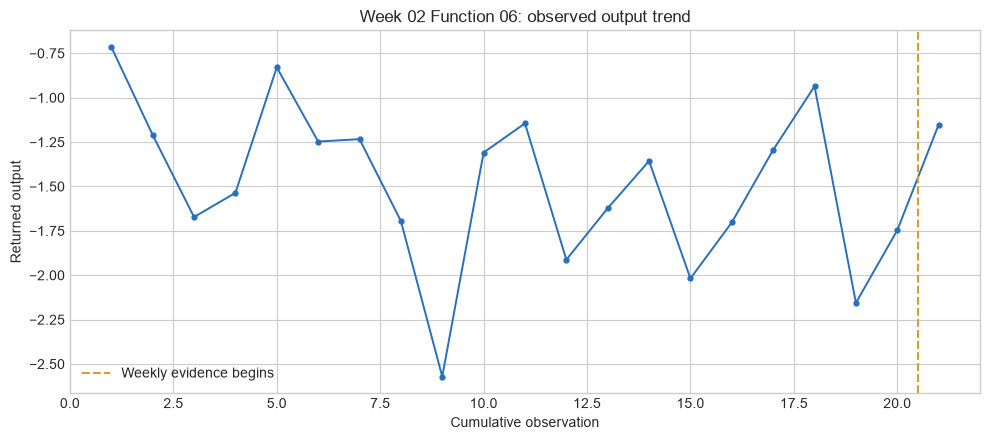

In [66]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

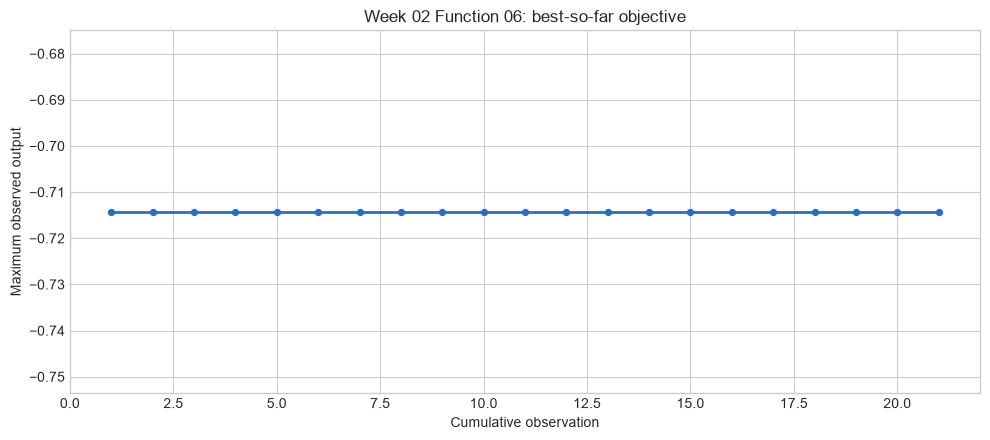

In [67]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [68]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,output
0,1,starter,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


## 8. Plot the correlation heatmap

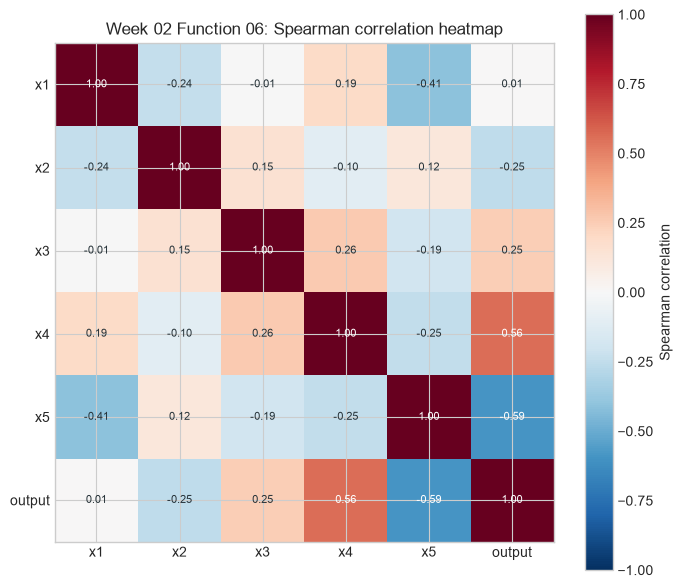

In [69]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

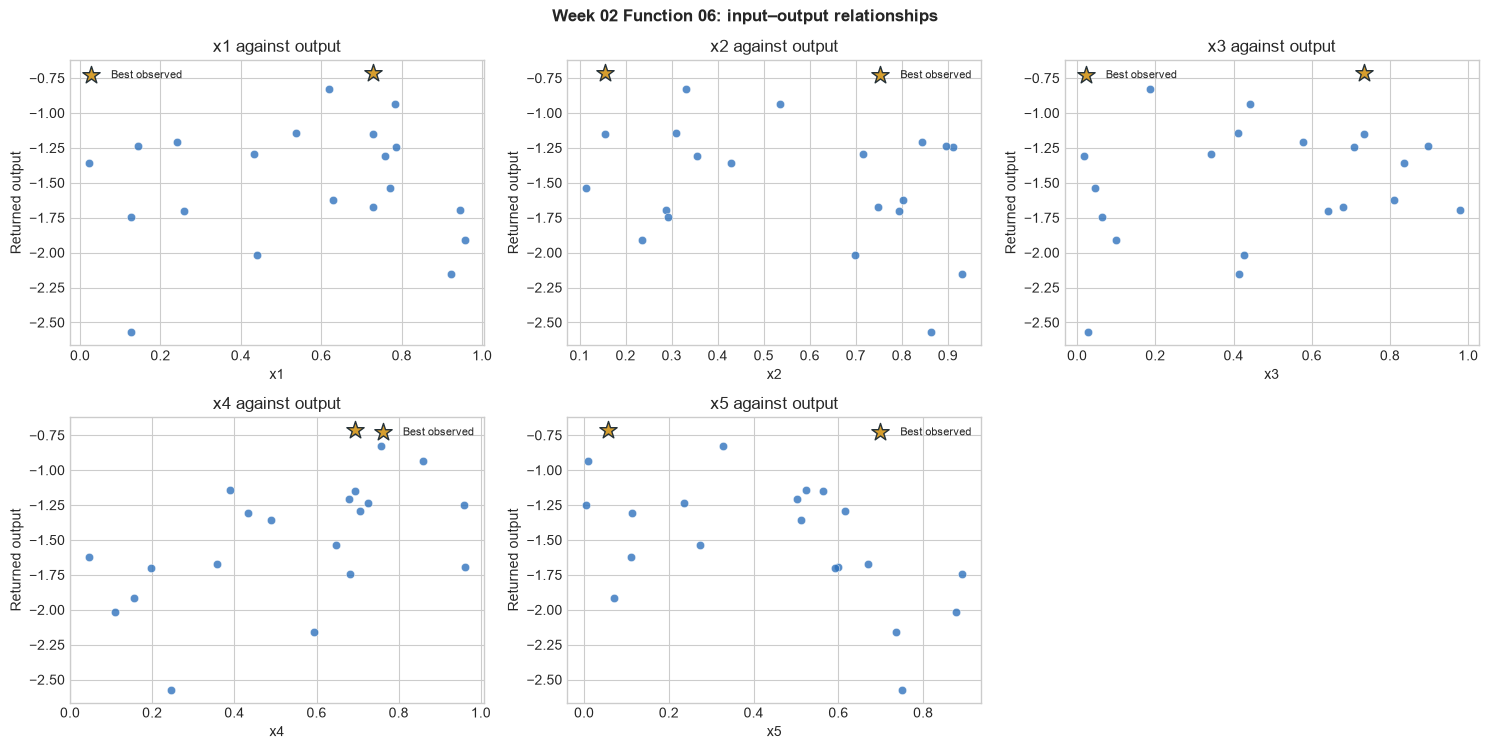

In [70]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [71]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.88**2 * Matern(length_scale=[0.629, 1.16, 1.39, 1.62, 1.29], nu=2.5) + WhiteKernel(noise_level=1e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [72]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_6:0.345768-0.101251-0.729498-0.863736-0.001121


,week,function,kappa,x1,x2,x3,x4,x5,predicted_mean,predicted_std,ucb_score,status
0,2,6,2.0,0.345768,0.101251,0.729498,0.863736,0.001121,-0.336505,0.357636,0.378767,proposed_not_evaluated


# Function 7

Function 7 uses the verified evidence available before Week 02.

In [73]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 7, 6, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [74]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,output
observation,,,,,,,,
21,starter,0.226348,0.115026,0.824750,0.945384,0.905312,0.951014,0.007016
22,starter,0.686853,0.041017,0.007573,0.285009,0.691568,0.655543,0.100507
23,starter,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396
24,starter,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142
25,starter,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457
26,starter,0.932466,0.488812,0.258608,0.956243,0.190428,0.519852,0.003777
27,starter,0.846867,0.142429,0.060669,0.756292,0.552398,0.081306,0.003134
28,starter,0.806282,0.324122,0.726076,0.148712,0.719376,0.362884,0.021343
29,starter,0.476823,0.340942,0.014335,0.880140,0.998655,0.079664,0.095411


## 2. Extract the function

In [75]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 7: 6 input dimensions, 31 verified observations


## 3. Check shapes and missing values

In [76]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(31, 6)"
1,output shape,"(31,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [77]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,31.0,0.495827,0.310325,0.045091,0.185615,0.541241,0.777431,0.942451
x2,31.0,0.400089,0.249477,0.011813,0.199998,0.397962,0.538417,0.924694
x3,31.0,0.387662,0.308953,0.003635,0.084639,0.329265,0.644549,0.924571
x4,31.0,0.499675,0.315332,0.073659,0.218099,0.449982,0.820098,0.961017
x5,31.0,0.466151,0.309498,0.014944,0.190980,0.434667,0.718908,0.998655
x6,31.0,0.489751,0.266303,0.051100,0.298887,0.585236,0.702187,0.951014
output,31.0,0.246426,0.337017,0.002701,0.018039,0.083747,0.375144,1.364968


## 5. Plot the output trend

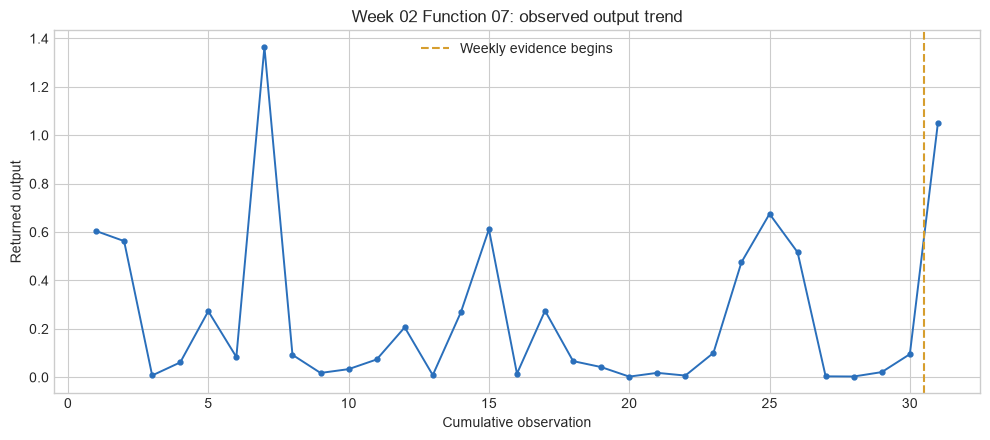

In [78]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

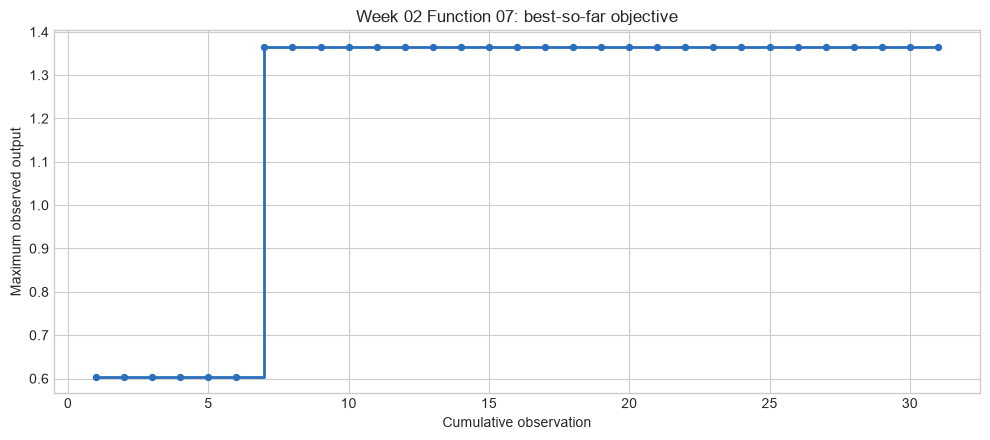

In [79]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [80]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,output
0,7,starter,0.057896,0.491672,0.247422,0.218118,0.420428,0.73097,1.364968


## 8. Plot the correlation heatmap

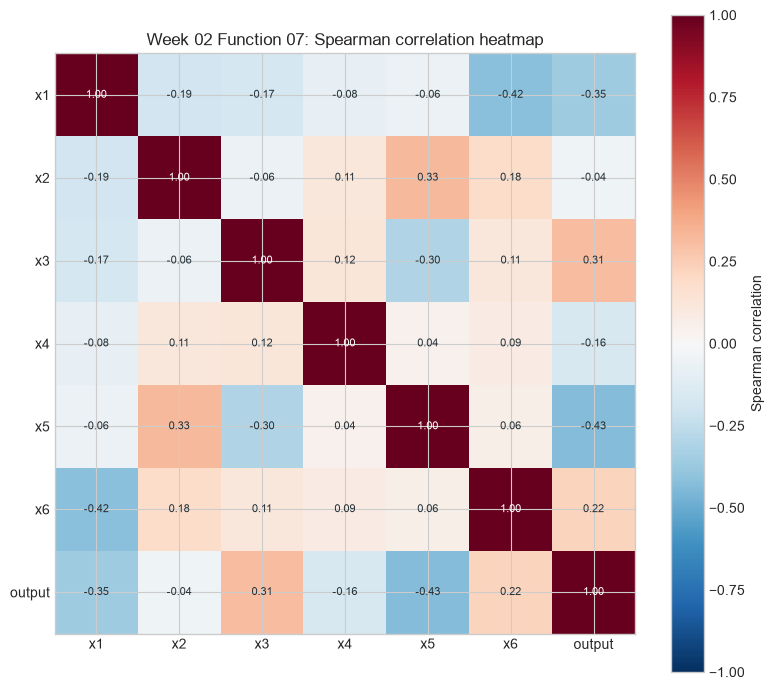

In [81]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

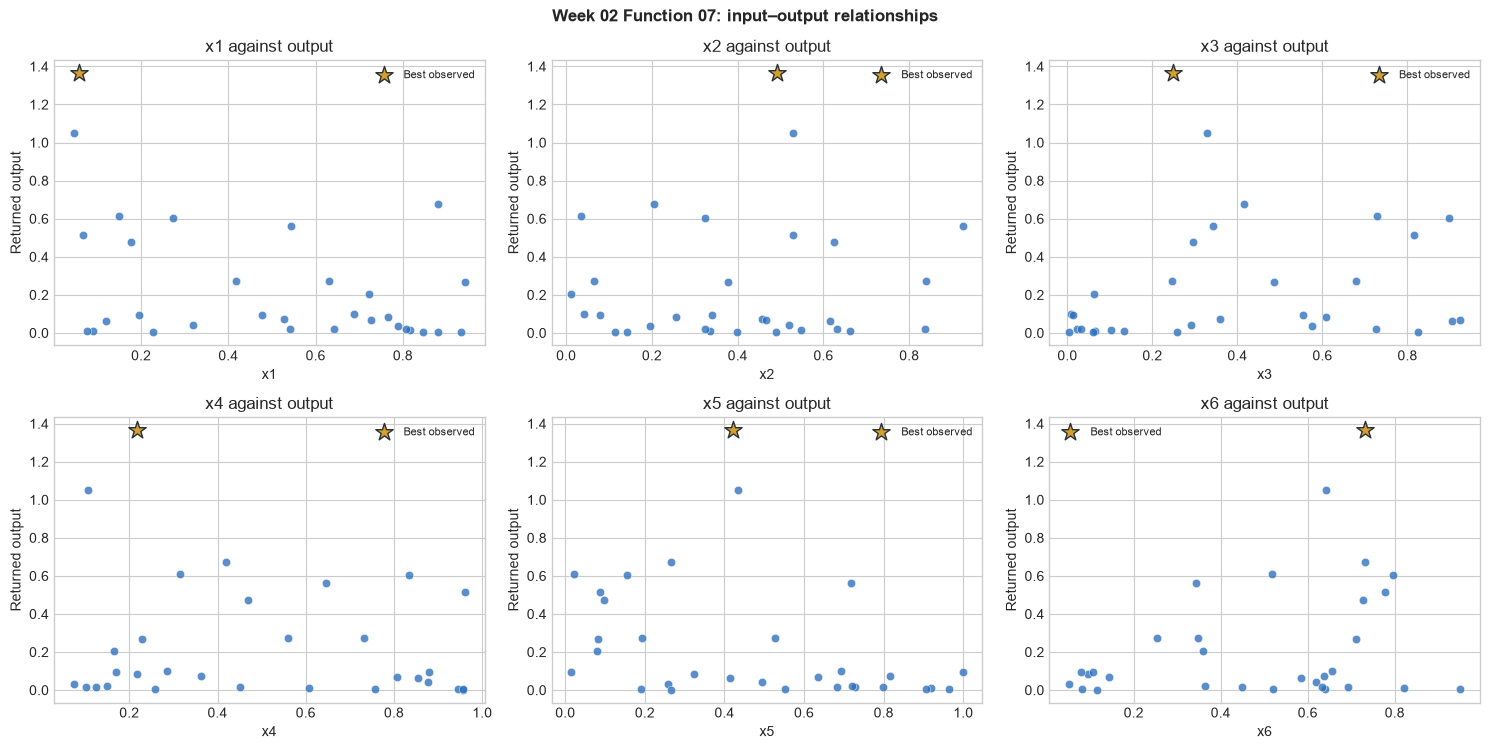

In [82]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [83]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.936**2 * Matern(length_scale=[1.06, 10, 10, 0.349, 0.196, 0.237], nu=2.5) + WhiteKernel(noise_level=1e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [84]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_7:0.260492-0.931384-0.286865-0.105588-0.380013-0.789367


,week,function,kappa,x1,x2,x3,x4,x5,x6,predicted_mean,predicted_std,ucb_score,status
0,2,7,2.0,0.260492,0.931384,0.286865,0.105588,0.380013,0.789367,1.173777,0.1683,1.510378,proposed_not_evaluated


# Function 8

Function 8 uses the verified evidence available before Week 02.

In [85]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 2, 8, 8, 1
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [86]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,x7,x8,output
observation,,,,,,,,,,
31,starter,0.532820,0.862308,0.538267,0.049443,0.719701,0.906706,0.108231,0.525348,8.421759
32,starter,0.394865,0.331802,0.740754,0.697862,0.737404,0.783777,0.254495,0.871146,8.278062
33,starter,0.985945,0.873054,0.070393,0.053587,0.734153,0.520259,0.811040,0.103360,7.113457
34,starter,0.964573,0.973980,0.663753,0.662216,0.673122,0.905238,0.458875,0.560918,6.402588
35,starter,0.472071,0.168203,0.086428,0.452656,0.480619,0.622439,0.928974,0.112536,8.472936
36,starter,0.856007,0.638894,0.326192,0.668503,0.240298,0.210299,0.167546,0.963590,7.977685
37,starter,0.810032,0.635046,0.269548,0.869605,0.661922,0.252259,0.765670,0.890549,7.460872
38,starter,0.796253,0.007037,0.355697,0.487566,0.740520,0.706650,0.992914,0.381734,7.436594
39,starter,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005


## 2. Extract the function

In [87]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 8: 8 input dimensions, 41 verified observations


## 3. Check shapes and missing values

In [88]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(41, 8)"
1,output shape,"(41,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [89]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,41.0,0.528245,0.309463,0.009077,0.273673,0.532721,0.791888,0.985945
x2,41.0,0.466985,0.307593,0.003419,0.218851,0.523642,0.699506,0.973980
x3,41.0,0.505188,0.287304,0.022929,0.281869,0.481372,0.729546,0.998885
x4,41.0,0.421866,0.263974,0.009043,0.177981,0.452656,0.662216,0.902986
x5,41.0,0.478545,0.284552,0.009649,0.240298,0.414579,0.730693,0.986902
x6,41.0,0.454531,0.276220,0.022113,0.244341,0.409325,0.706650,0.990244
x7,41.0,0.567720,0.265058,0.035909,0.410153,0.592415,0.765670,0.992914
x8,41.0,0.502961,0.278849,0.041956,0.295518,0.524885,0.728611,0.988755
output,41.0,7.864066,0.997111,5.592193,7.299872,7.923759,8.541748,9.815709


## 5. Plot the output trend

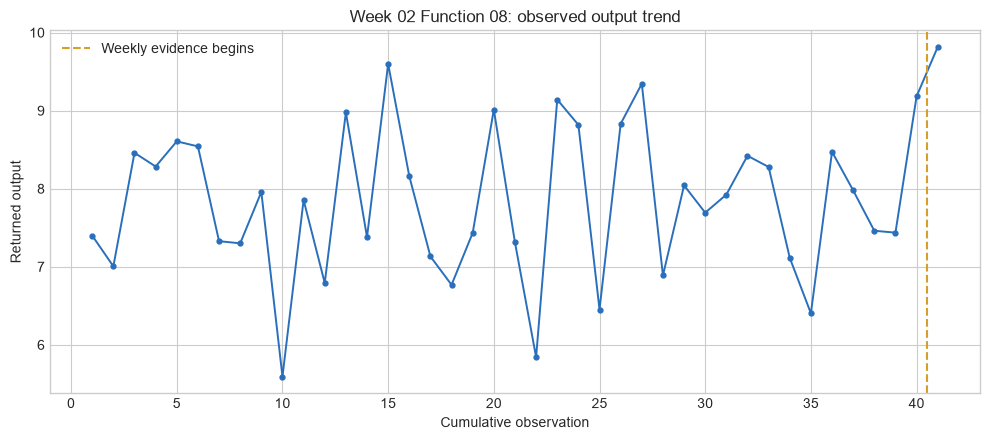

In [90]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

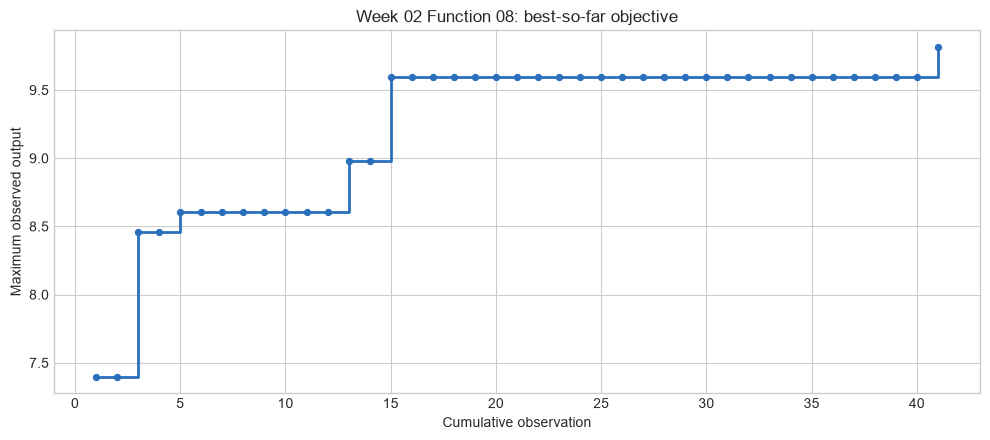

In [91]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [92]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,x7,x8,output
0,41,week_01,0.273673,0.2604,0.073937,0.078562,0.862321,0.230729,0.108688,0.352588,9.815709


## 8. Plot the correlation heatmap

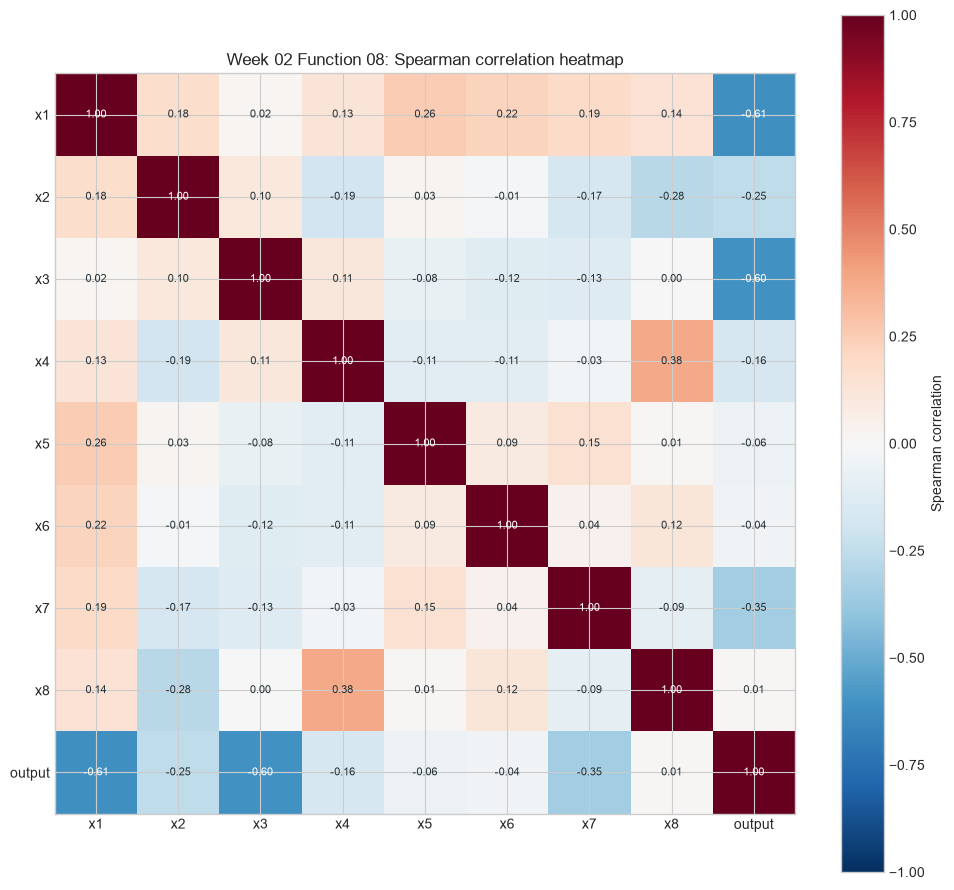

In [93]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

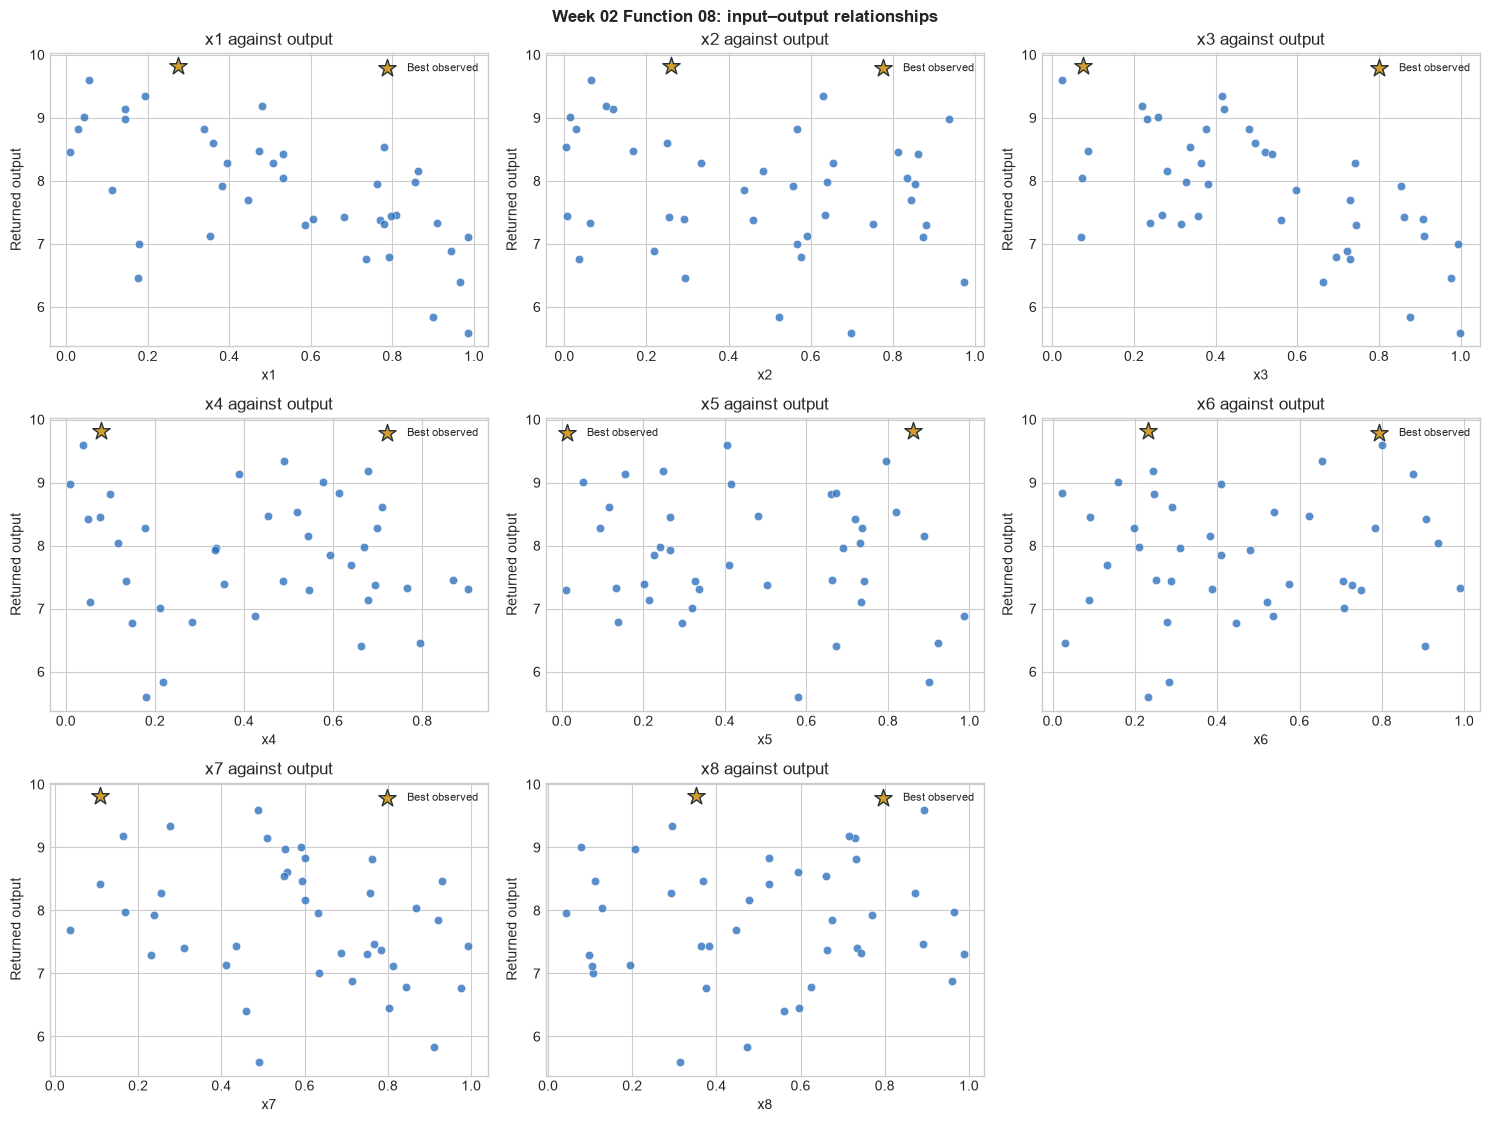

In [94]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [95]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.42**2 * Matern(length_scale=[3.12, 4.28, 2.18, 10, 10, 4.24, 3.08, 10], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [96]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_8:0.207938-0.003978-0.033243-0.090783-0.897724-0.722382-0.007345-0.895878


,week,function,kappa,x1,x2,x3,x4,x5,x6,x7,x8,predicted_mean,predicted_std,ucb_score,status
0,2,8,2.0,0.207938,0.003978,0.033243,0.090783,0.897724,0.722382,0.007345,0.895878,9.862455,0.185028,10.232512,proposed_not_evaluated
